In [1]:
from langchain.llms import OpenAI
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import graphviz
from IPython.display import display, Image 
import re

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
load_dotenv()

# You can replace os.getenv('team_token') with a string containing the token, I just did it this way for more security
os.environ['OPENAI_API_KEY'] = os.getenv('team_token')

In [4]:
llm = OpenAI()

dsa_2214 = os.getenv('dsa_2214')

chapters = {
    'Chapter 1': 'Data Structures and Algorithms',
    'Chapter 2': 'Mathematical Preliminaries',
    'Chapter 3': 'Algorithm Analysis',
    'Chapter 4': 'Lists, Stacks, and Queues',
    'Chapter 5': 'Binary Trees',
    'Chapter 6': 'Non-Binary Trees',
    'Chapter 7': 'Internal Sorting',
    'Chapter 8': 'File Processing and External Sorting',
    'Chapter 9': 'Searching',
    'Chapter 10': 'Indexing',
    'Chapter 11': 'Graphs',
    'Chapter 12': 'Lists and Arrays Revisited',
    'Chapter 13': 'Advanced Tree Structures',
    'Chapter 14': 'Analysis Techniques',
    'Chapter 15': 'Lower Bounds',
    'Chapter 16': 'Patterns of Algorithms',
    'Chapter 17': 'Limits to Computation'
}

In [5]:
learning_concepts_list = []
learning_outcomes_list = []

for chapter, chapter_name in chapters.items():
    learning_concept = llm(f"Please identify the main learning concepts given {chapter}, the chapter name is {chapter_name}. Here is the textbook in which to retrieve them: {dsa_2214}")
    learning_concept = re.sub(re.compile('[^a-zA-Z\s\.,!?]'), '', learning_concept)
    learning_concepts_list.append(learning_concept)

    learning_outcome = llm(f"Please identify the main learning outcomes given {chapter}, the chapter name is {chapter_name}. Here is the textbook in which to retrieve them: {dsa_2214}")
    learning_outcome = re.sub(re.compile('[^a-zA-Z\s\.,!?]'), '', learning_outcome)
    learning_outcomes_list.append(learning_outcome)

In [5]:
# Run 5 times and compare results, do this twice 

common_concepts_dict = {}
common_outcomes_dict = {}

for name in chapters.values():
    common_concepts_dict[name] = ([], [])
    common_outcomes_dict[name] = ([], [])

for i in range(2):
    for j in range(5):
        for chapter, chapter_name in chapters.items():
            learning_concept = llm(f"Please identify the main learning concepts given {chapter}, the chapter name is {chapter_name}. Here is the textbook in which to retrieve them: {dsa_2214}. Please limit your answer to 20 concepts and provide them in a list format.")
            learning_concept = re.sub(re.compile('[^a-zA-Z\s\.,!?]'), '', learning_concept)
            print(learning_concept.split('\n'))
            common_concepts_dict[chapter_name][i].append([concept for concept in learning_concept.split('\n')[2:] if concept != ''])
    
            learning_outcome = llm(f"Please identify the main learning outcomes given {chapter}, the chapter name is {chapter_name}. Here is the textbook in which to retrieve them: {dsa_2214}. Please limit your answer to 20 outcomes and provide them in a list format.")
            learning_outcome = re.sub(re.compile('[^a-zA-Z\s\.,!?]'), '', learning_outcome)
            common_outcomes_dict[chapter_name][i].append([outcome for outcome in learning_outcome.split('\n')[2:] if outcome != ''])


['', '', '. Data structures', '. Algorithms', '. Complexity analysis', '. Efficiency', '. Abstract data types', '. Data abstraction', '. Objectoriented programming', '. Arrays', '. Linked lists', '. Stacks', '. Queues', '. Trees', '. Graphs', '. Recursion', '. Sorting', '. Searching', '. Hashing', '. Binary search trees', '. Heaps', '. Priority queues']
['', '. Data types', '. Variables', '. Operators', '. Arithmetic operations', '. Relational operations', '. Logical operations', '. Expressions', '. Precedence rules', '. Assignment statements', '. Control structures', '. Conditional statements', '. Loops', '. Arrays', '. Indexing', '. Multidimensional arrays', '. Strings', '. Character encoding', '. Bitwise operations', '. Floatingpoint representation', '. Mathematical functions']
['', '', '. Analysis of algorithms', '. Efficiency and complexity', '. Asymptotic analysis', '. BigO notation', '. Time complexity', '. Space complexity', '. Worstcase, bestcase, and averagecase analysis', '.

In [6]:
in_common_concepts = {}
in_common_outcomes = {}

for key in chapters.values():
    in_common_concepts[key] = []
    in_common_outcomes[key] = []

first_key = list(common_concepts_dict.keys())[0]

for idx in range(len(common_concepts_dict[first_key])):
    for chapter_name, chapter_concepts in common_concepts_dict.items():
        content = llm(f"Please identify the common concepts between these lists of concepts for chapter {chapter_name}? {chapter_concepts[idx][0]}, {chapter_concepts[idx][1]}, {chapter_concepts[idx][2]}, {chapter_concepts[idx][3]}, {chapter_concepts[idx][4]}? Please limit your response to 20 concepts in a list format.")
        in_common_concepts[chapter_name].append(content.split('\n')[2:])
    
    for chapter_name, chapter_outcomes in common_outcomes_dict.items():
        content = llm(f"Please identify the common learning outcomes between these lists for chapter {chapter_name}? {chapter_outcomes[idx][0]}, {chapter_outcomes[idx][1]}, {chapter_outcomes[idx][2]}, {chapter_outcomes[idx][3]}, {chapter_outcomes[idx][4]}? Please limit your response to 20 outcomes in a list format.")
        in_common_outcomes[chapter_name].append(content.split('\n')[2:])


In [7]:
final_common_concept_dict = {}
final_common_outcome_dict = {}

for key in in_common_concepts.keys():
    content = llm(f"Please identify the common concepts between these two lists: {in_common_concepts[key][0]}, {in_common_concepts[key][1]}")
    final_common_concept_dict[key] = [concept for concept in content.split('\n')[2:] if concept.strip() != '']

    content = llm(f"Please identify the common learning outcomes between these two lists: {in_common_outcomes[key][0]}, {in_common_outcomes[key][1]}")
    final_common_outcome_dict[key] = [outcome for outcome in content.split('\n')[2:] if outcome.strip() != '']


In [8]:
final_common_concept_dict

{'Data Structures and Algorithms': ['1. Data structures',
  '2. Algorithms',
  '3. Efficiency analysis',
  '4. Abstract data types',
  '5. Recursion',
  '6. Sorting algorithms',
  '7. Searching algorithms',
  '8. Hashing',
  '9. Linked lists',
  '10. Stacks',
  '11. Queues',
  '12. Trees',
  '13. Graphs',
  '14. Dynamic programming',
  '15. Divide and conquer',
  '16. Greedy algorithms',
  '17. Big O notation',
  '18. Memory management',
  '19. Computational thinking'],
 'Mathematical Preliminaries': ['Variables, operators, arithmetic operations, relational operations, logical operations, expressions, assignment statements, control structures, conditional statements, loops, arrays, indexing, multidimensional arrays, strings, bitwise operations, floating-point representation, mathematical functions, number systems.'],
 'Algorithm Analysis': ['- Efficiency',
  '- Complexity',
  '- Time complexity',
  '- Space complexity',
  '- Asymptotic analysis',
  '- BigO notation',
  '- Worstcase ana

In [17]:
import warnings
warnings.filterwarnings('ignore')

keys = list(final_common_concept_dict.keys())
dependencies = {}

for key in keys:
    dependencies[key] = []

for i in range(len(keys)):
    current_concept = final_common_concept_dict[keys[i]]
    for j in range(i + 1, len(keys)):
        next_concept = final_common_concept_dict[keys[j]]
        content = llm(f"Please identify if this list of concepts: {next_concept} has a prerequisite for this list of concepts: {current_concept}. If there is NO prerequisite, please respond with 'No' and 'No' only.")
        print(f"Current concept: {current_concept},\nnext concept: {next_concept}")
        print(f"Current Chapter Name: {keys[i]}, Next Chapter Name: {keys[j]}, LLM: {content}")
        if content.split(',')[0].strip() != 'No':
            dependencies[keys[j]].append(keys[i])
            
dependencies

Current concept: ['1. Data structures', '2. Algorithms', '3. Efficiency analysis', '4. Abstract data types', '5. Recursion', '6. Sorting algorithms', '7. Searching algorithms', '8. Hashing', '9. Linked lists', '10. Stacks', '11. Queues', '12. Trees', '13. Graphs', '14. Dynamic programming', '15. Divide and conquer', '16. Greedy algorithms', '17. Big O notation', '18. Memory management', '19. Computational thinking']
, next concept: ['Variables, operators, arithmetic operations, relational operations, logical operations, expressions, assignment statements, control structures, conditional statements, loops, arrays, indexing, multidimensional arrays, strings, bitwise operations, floating-point representation, mathematical functions, number systems.']
Current Chapter Name: Data Structures and Algorithms, Next Chapter Name: Mathematical Preliminaries, LLM: 

No, there is no prerequisite for this list of concepts.
Current concept: ['1. Data structures', '2. Algorithms', '3. Efficiency analys

KeyboardInterrupt: 

In [10]:
import graphlib
sorted_dependencies = graphlib.TopologicalSorter(graph = dependencies)
sorted_dependencies = tuple(sorted_dependencies.static_order())
print(sorted_dependencies)

('Data Structures and Algorithms', 'Algorithm Analysis', 'Binary Trees', 'Lists and Arrays Revisited', 'Mathematical Preliminaries', 'Lists, Stacks, and Queues', 'Non-Binary Trees', 'File Processing and External Sorting', 'Searching', 'Indexing', 'Internal Sorting', 'Graphs', 'Advanced Tree Structures', 'Analysis Techniques', 'Lower Bounds', 'Patterns of Algorithms', 'Limits to Computation')


{'Data Structures and Algorithms': [], 'Algorithm Analysis': [], 'Binary Trees': [], 'Lists and Arrays Revisited': [], 'Mathematical Preliminaries': ['Data Structures and Algorithms'], 'Lists, Stacks, and Queues': ['Data Structures and Algorithms'], 'Non-Binary Trees': ['Binary Trees'], 'File Processing and External Sorting': ['Mathematical Preliminaries', 'Binary Trees'], 'Searching': ['Algorithm Analysis', 'Lists, Stacks, and Queues'], 'Indexing': ['Lists, Stacks, and Queues', 'Binary Trees'], 'Internal Sorting': ['Data Structures and Algorithms', 'Lists, Stacks, and Queues', 'Non-Binary Trees'], 'Graphs': ['Non-Binary Trees'], 'Advanced Tree Structures': ['Data Structures and Algorithms', 'Mathematical Preliminaries', 'Non-Binary Trees'], 'Analysis Techniques': ['Advanced Tree Structures'], 'Lower Bounds': ['Data Structures and Algorithms', 'Lists, Stacks, and Queues', 'Internal Sorting', 'Advanced Tree Structures', 'Analysis Techniques'], 'Patterns of Algorithms': ['Data Structures

/home/zhutchens/anaconda3/lib/python3.11/site-packages/hypernetx/classes/entityset.py:150: DeprecationWarning: misc_props_col and misc_cell_props_col will be deprecated; all public references to these arguments will be removed in a future release.
  warnings.warn(
/home/zhutchens/anaconda3/lib/python3.11/site-packages/hypernetx/classes/hypergraph.py:563: FutureWarning: This method or function will be deprecated in a future release. Public references to this method or function will be removed from the Hypergraph API in a future release.
  self._nodes = self.E.restrict_to_levels([1])
/home/zhutchens/anaconda3/lib/python3.11/site-packages/hypernetx/classes/entityset.py:618: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  elements = self._dataframe.groupby(col1)[col2].unique().to_dict()
/home/zhutchens/

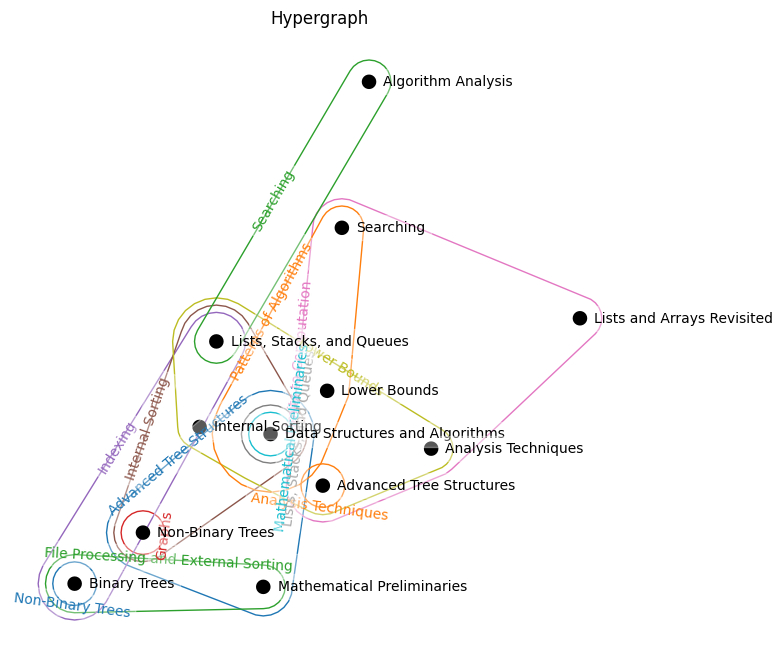

In [13]:
from hypernetx import draw, Hypergraph

temp = sorted_dependencies
sorted_dependencies = {}

for value in temp:
    sorted_dependencies[value] = dependencies[value]

print(sorted_dependencies)

draw(Hypergraph(sorted_dependencies))
plt.title('Hypergraph')
plt.show()

/home/zhutchens/anaconda3/lib/python3.11/site-packages/py3plex-0.95a0-py3.11.egg/py3plex/visualization/fa2/forceatlas2.py:260: DeprecationWarning: 

The scipy.sparse array containers will be used instead of matrices
in Networkx 3.0. Use `to_scipy_sparse_array` instead.
  M = networkx.to_scipy_sparse_matrix(G, dtype='f', format='lil')


-------------------- 
 Network splitting in progress 
 --------------------


100%|██████████| 100/100 [00:00<00:00, 6968.56it/s]
/home/zhutchens/anaconda3/lib/python3.11/site-packages/py3plex-0.95a0-py3.11.egg/py3plex/visualization/multilayer.py:124: DeprecationWarning: info is deprecated and will be removed in version 3.0.

  print(nx.info(network))


BarnesHut Approximation  took  0.00  seconds
Repulsion forces  took  0.01  seconds
Gravitational forces  took  0.00  seconds
Attraction forces  took  0.00  seconds
AdjustSpeedAndApplyForces step  took  0.00  seconds
Finished with layout..
MultiDiGraph with 1 nodes and 0 edges
MultiDiGraph with 1 nodes and 0 edges
MultiDiGraph with 1 nodes and 0 edges
MultiDiGraph with 1 nodes and 0 edges
MultiDiGraph with 1 nodes and 0 edges
MultiDiGraph with 1 nodes and 0 edges
MultiDiGraph with 1 nodes and 0 edges
MultiDiGraph with 1 nodes and 0 edges
MultiDiGraph with 1 nodes and 0 edges
MultiDiGraph with 1 nodes and 0 edges
MultiDiGraph with 1 nodes and 0 edges
MultiDiGraph with 1 nodes and 0 edges
MultiDiGraph with 1 nodes and 0 edges
MultiDiGraph with 1 nodes and 0 edges
MultiDiGraph with 1 nodes and 0 edges
MultiDiGraph with 1 nodes and 0 edges
MultiDiGraph with 1 nodes and 0 edges


100%|██████████| 1/1 [00:00<00:00, 53.28it/s]


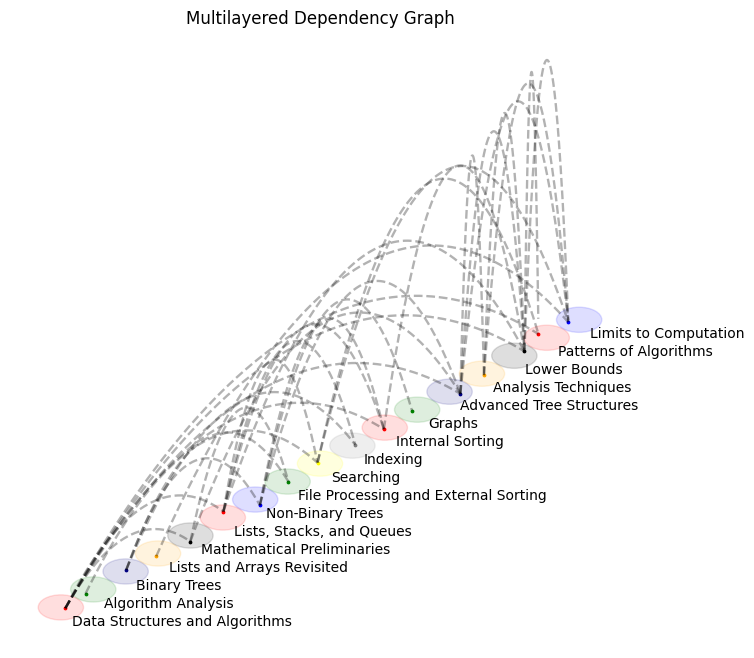

In [14]:
from py3plex.core import multinet

multi_graph = multinet.multi_layer_network(network_type = "multiplex")

for node, edges in sorted_dependencies.items():
    node_data = {"source": node, "type": node}
    multi_graph.add_nodes(node_data)
    for edge in edges:
        simple_edge = {
                "source": node,
                "target": edge,
                "source_type": node,
                "target_type": edge
                }
        
        multi_graph.add_edges(simple_edge, input_type = "dict") 

multi_graph.visualize_network(style = "diagonal")
plt.title("Multilayered Dependency Graph")
plt.show()

In [ ]:
# Create learning concept graph association structure
learning_concept_graph = {}
for idx, name in enumerate(chapters.values()):
    learning_concept_graph[name] = (learning_concepts_list[idx], learning_outcomes_list[idx])

# Dictionary structure now:
# The key is the chapter title, and the value is a tuple containing the learning concept(s) at index 0, and outcome(s) at index 1
learning_concept_graph

In [ ]:
association_dict = {}

for name in chapters.values():
    association_dict[name] = []

# Build associations algorithm
for i in range(len(list(learning_concept_graph.values()))):
    current_tuple = list(learning_concept_graph.values())[i]
    for j in range(i + 1, len(list(learning_concept_graph.values()))):
        next_tuple = list(learning_concept_graph.values())[j]
        print(f"Current concept: {current_tuple[0]}, next concept: {next_tuple[0]}")
        new_association = llm(f"Please identify if there is an association between this concept: {current_tuple[0]}, and this other concept: {next_tuple[0]}. If there is NO association, please start your response with 'No' and 'No' only.")
        new_association = re.sub(re.compile('[^a-zA-Z\s\.,!?]'), '', new_association)
        # Try to only add associations to the graph, but its difficult because sometimes the LLM won't start its response with 'No'
        if new_association.split(',')[0].strip() != 'No':
            association_dict[list(learning_concept_graph.keys())[i]].append(list(learning_concept_graph.keys())[j])


In [ ]:
association_dict

In [ ]:
graph = graphviz.Digraph(name = "Learning Concept Associations")

for key, values in association_dict.items():
    graph.node(name = key)
    for value in values:
        graph.edge(key, value)

display(Image(graph.pipe(format = "png", renderer = "cairo")))

In [ ]:
from pyvis.network import Network

graph = Network(notebook = True, cdn_resources = "remote")

graph.toggle_physics(False)

# Showing all interactivity options, but can be parameterized to only include some
graph.show_buttons()

node_id_dict = {}
count = 1
for name in list(learning_concept_graph.keys()):
    node_id_dict[name] = count
    count += 1

for chapter_name, chapter_id in node_id_dict.items():
    graph.add_node(n_id = chapter_id, label = chapter_name, title = "Main Learning Concepts: " + learning_concept_graph[chapter_name][0] + "\n" + "Main Learning Outcomes:" + learning_concept_graph[chapter_name][1])

for key, values in association_dict.items():
    for value in values:
        graph.add_edge(node_id_dict[key], node_id_dict[value])

graph.show(name = "interactive.html")

In [ ]:
topics = llm(f"Can you give 10 main topics from this textbook? {dsa_2214}")
topics = topics.split('\n')
for topic in topics:
    print(topic)

In [ ]:
main_concept_graph = {}

for topic in topics[2:]:
    main_concept_graph[topic] = []
main_concept_graph.keys()

In [ ]:
for i in range(2, len(topics)):
    for j in range(2, len(topics)):
        if i != j:
            association = llm(f'Are there any associations between {topics[i]} and {topics[j]}? If there are NOT, please respond with "No" and "No" only.')
            association = re.sub(re.compile('[^a-zA-Z\s\.,!?]',), '', association)
            if association.split()[0] != 'No':
                main_concept_graph[topics[i]].append(topics[j])

In [ ]:
main_graph = graphviz.Digraph(name = "Main Concept Graph")

for key in main_concept_graph.keys():
    main_graph.node(name = key)

for key, values in main_concept_graph.items():
    for value in values:
        main_graph.edge(key, value)

display(Image(main_graph.pipe(format = "png", renderer = "cairo")))

Task 3 Subtask 1


In [ ]:
i = 1
for key, value in learning_concept_graph.items():
    print(f'CHAPTER: {i}')
    print(key)
    print('') # just for a cleaner output
    i += 1


In [ ]:
relations = {}
keys = list(learning_concept_graph.keys())
values = list(learning_concept_graph.values())

for key in keys:
    relations[key] = []

def check_feedback_loop(relation_dict: dict, starting: str, ending: str) -> bool:
    if starting == ending:
        return True
    else:
        visited_concepts = []
        tracking_lst = [starting]
        while tracking_lst:
            current_concept = tracking_lst.pop()
            if current_concept == ending:
                return True
            visited_concepts.append(current_concept)
            tracking_lst = [concept for concept in relation_dict.get(current_concept) if concept not in visited_concepts]
        return False


# Should this not be the other way around? It doesnt make sense to start at chapter 1 and ask if it depends on other chapters
# for i in range(len(values)):
#     current_tuple = values[i]
#     for j in range(i + 1, len(values)):
        
#         next_tuple = values[j]
        
#         new_dependency = llm(f"Please identify if this concept: {current_tuple[0]} has a dependency for this concept: {next_tuple[0]}. If there is NO dependency, please start your response with 'No' and 'No' only.")
#         new_dependency = re.sub(re.compile('[^a-zA-Z\s\.,!?]'), '', new_dependency)
        
#         # Try to only add associations to the graph, but its difficult because sometimes the LLM won't start its response with 'No'
#         if new_dependency.split(',')[0].strip() != 'No' and not check_feedback_loop(relations, keys[j], keys[i]):
#             relations[keys[i]].append(keys[j])


# loop the other way 
# for i in range(len(values) - 1, -1, -1):
#     for j in range(i - 1, -1, -1):
#         current_tuple = values[i]
#         next_tuple = values[j]
        
#         new_dependency = llm(f"Please identify if this concept: {current_tuple[0]} has a dependency for this concept: {next_tuple[0]}. If there is NO dependency, please start your response with 'No' and 'No' only.")
#         print(new_dependency)
#         new_dependency = re.sub(re.compile('[^a-zA-Z\s\.,!?]'), '', new_dependency)
        
#         # Try to only add associations to the graph, but its difficult because sometimes the LLM won't start its response with 'No'
#         if new_dependency.split(',')[0].strip() != 'No' and not check_feedback_loop(relations, keys[j], keys[i]):
#             relations[keys[i]].append(keys[j])
# relations

# Run 10 times and compare graphs
for i in range(10):
    
    relations = {}
    keys = list(learning_concept_graph.keys())
    values = list(learning_concept_graph.values())

    for key in keys:
        relations[key] = []
    
    for i in range(len(values) - 1, -1, -1):
        for j in range(i - 1, -1, -1):
            current_tuple = values[i]
            next_tuple = values[j]
            
            new_dependency = llm(f"Please identify if this concept: {current_tuple[0]} has a prerequisite for this concept: {next_tuple[0]}. If there is NO dependency, please start your response with 'No' and 'No' only.")
            new_dependency = re.sub(re.compile('[^a-zA-Z\s\.,!?]'), '', new_dependency)
            
            # Try to only add associations to the graph, but its difficult because sometimes the LLM won't start its response with 'No'
            if new_dependency.split(',')[0].strip() != 'No' and not check_feedback_loop(relations, keys[j], keys[i]):
                relations[keys[i]].append(keys[j])

    directed_graph = graphviz.Digraph()

    for key, values in relations.items():
        directed_graph.node(name = key)
        for value in values:
            directed_graph.edge(key, value)

    display(Image(directed_graph.pipe(format = "png", renderer = "cairo")))

Task 3 Subtask 2

In [ ]:
directed_graph = graphviz.Digraph()

for key, values in relations.items():
    directed_graph.node(name = key)
    for value in values:
        directed_graph.edge(key, value)

display(Image(directed_graph.pipe(format = "png", renderer = "cairo")))